<a href="https://colab.research.google.com/github/krishnasaijoga/ScalerCaseStudies/blob/main/E_Commerce_Marketing_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Load and Handling

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sales_data = pd.read_csv("/content/Online_Sales.csv")
tax_amount_data = pd.read_excel("/content/Tax_amount.xlsx")
discount_coupon_data = pd.read_csv("/content/Discount_Coupon.csv")
customers_data = pd.read_excel("/content/CustomersData.xlsx")
marketing_spend_data = pd.read_csv("/content/Marketing_Spend.csv")
# marketing_spend_data.info()

In [ ]:
# convert to date
sales_data['Transaction_Date'] = pd.to_datetime(sales_data['Transaction_Date'])
marketing_spend_data['Date'] = pd.to_datetime(marketing_spend_data['Date'])
sales_data['order_month'] = sales_data['Transaction_Date'].dt.to_period('M')
sales_data['revenue'] = sales_data['Quantity'] * sales_data['Avg_Price'] + sales_data['Delivery_Charges']

# Q1

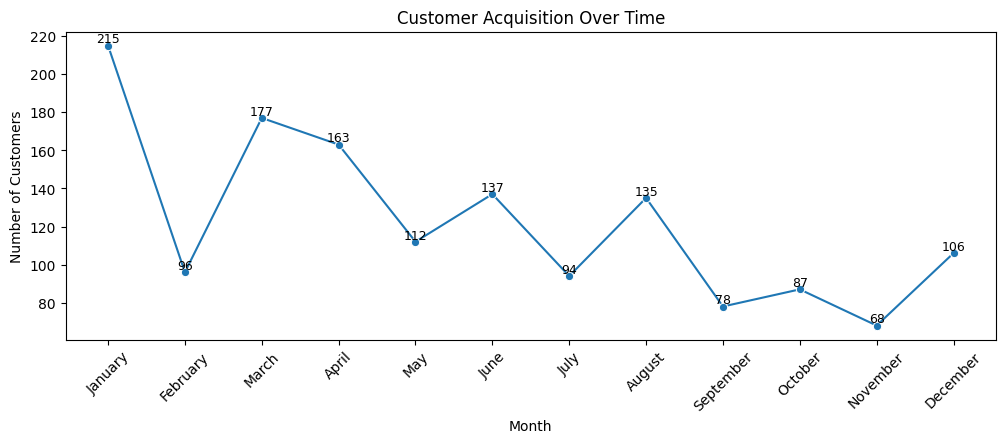

Top 3 Months with Acuisition count
    month  Customer_count
 January             215
February              96
   March             177
Bottom 3 Months with Acuisition count
    month  Customer_count
 October              87
November              68
December             106


In [ ]:
customer_group = sales_data.groupby('CustomerID')['Transaction_Date'].first()
customer_group = pd.DataFrame(customer_group)
customer_group.reset_index(inplace=True)
customer_group['month'] = customer_group['Transaction_Date'].dt.month_name()
month_acquisition = pd.DataFrame(customer_group.groupby('month')['CustomerID'].count())
month_acquisition.rename(columns={'CustomerID': 'Customer_count'}, inplace=True)
month_acquisition.reset_index(inplace=True)
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
cat_type = pd.CategoricalDtype(categories=month_order, ordered=True)
month_acquisition['month'] = month_acquisition['month'].str.title().astype(cat_type)
month_acquisition.sort_values(by='month', inplace=True)
plt.figure(figsize=(12, 4))
sns.lineplot(data=month_acquisition, x= 'month', y='Customer_count', marker='o')
for index, row in month_acquisition.iterrows():
    plt.text(row['month'], row['Customer_count'],
             f"{row['Customer_count']}",
             ha='center', va='bottom', fontsize=9, color='black')
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Number of Customers')
plt.title('Customer Acquisition Over Time')
plt.show()

print("Top 3 Months with Acuisition count\n", month_acquisition.head(3).to_string(index=False))
print("Bottom 3 Months with Acuisition count\n", month_acquisition.tail(3).to_string(index=False))

# Marketing strategies for Top months can be replicated to increase acquisition in least ones

# Q2

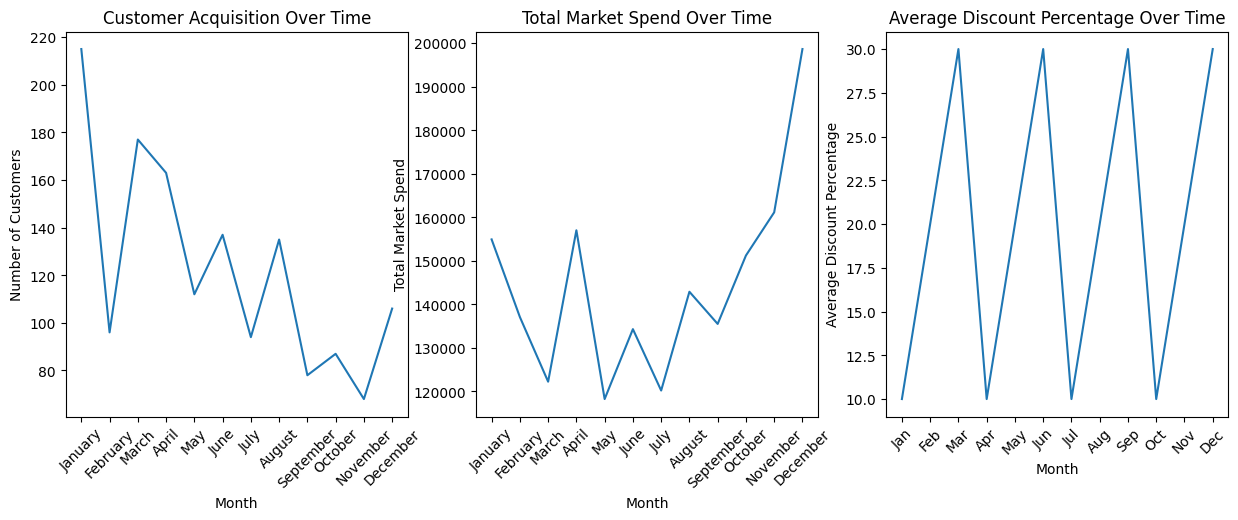

In [ ]:
# marketing_spend_data.head()
marketing_spend_data['month'] = marketing_spend_data['Date'].dt.month_name()
marketspend_monthly = pd.DataFrame(marketing_spend_data.groupby('month')[['Online_Spend','Offline_Spend']].sum())
marketspend_monthly['Total_Spend'] = marketspend_monthly['Online_Spend'] + marketspend_monthly['Offline_Spend']
marketspend_monthly.reset_index(inplace=True)
marketspend_monthly['month'] = marketspend_monthly['month'].str.title().astype(cat_type)

discount_monthly = pd.DataFrame(discount_coupon_data.groupby('Month')['Discount_pct'].mean())
discount_monthly.reset_index(inplace=True)
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
cat_type = pd.CategoricalDtype(categories=month_order, ordered=True)
discount_monthly['Month'] = discount_monthly['Month'].str.title().astype(cat_type)
discount_monthly.sort_values(by='Month', inplace=True)
discount_monthly.rename(columns={'Month': 'month', 'Discount_pct':'Discount_monthly_avg'}, inplace=True)
# discount_monthly.head()

fig, axes = plt.subplots(ncols=3, figsize=(15, 5), sharex=False, sharey=False)
sns.lineplot(data=month_acquisition, x= 'month', y='Customer_count', ax=axes[0])
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Customer Acquisition Over Time')
axes[0].tick_params(axis='x', rotation=45)
# axes[0]=axes[1].twiny()

sns.lineplot(data=marketspend_monthly, x='month', y='Total_Spend', ax=axes[1])
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Market Spend')
axes[1].set_title('Total Market Spend Over Time')
axes[1].tick_params( axis='x',rotation=45)

sns.lineplot(data=discount_monthly, x='month', y='Discount_monthly_avg', ax=axes[2])
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Average Discount Percentage')
axes[2].set_title('Average Discount Percentage Over Time')
axes[2].tick_params( axis='x',rotation=45)
plt.show()
# marketspend_monthly.head()


# Cosnistency of each month cannot be said because data only has for single year (2019)
# Looking into Market spend and discount average, we can clearly see Feb has lowest acquisition count and maerket spend -> So increase in market spend can show improvement similar to March month

# Q3

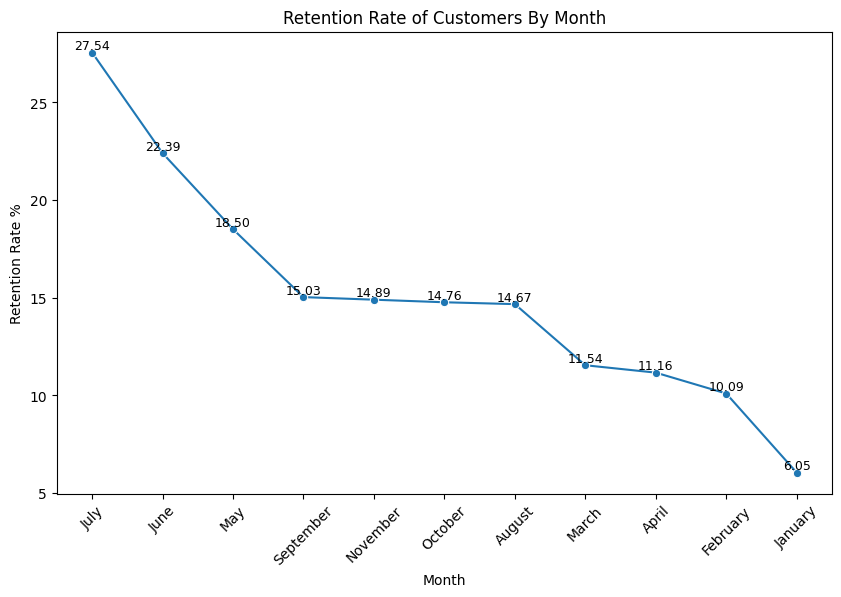

In [ ]:
#get customer-month pairs using assign function
pairs = sales_data.loc[:,['CustomerID','Transaction_Date']].assign(month=lambda x:x['Transaction_Date'].dt.to_period('M')).drop_duplicates(['CustomerID','month'])
#extract base month and customer count
base = pairs.groupby('month')['CustomerID'].nunique().rename('monthly_customers')
#extract curretn mmonth pairs
current_month = pairs.rename(columns={'month':'current_month'}).assign(month_next = lambda x:x['current_month']+1)
#extract next month pairs
next_month = pairs.rename(columns={'month':'month_next'})
#join both this month and next month to find retained customers
month_merge = current_month.merge(next_month, on=['CustomerID', 'month_next'], how='inner').groupby('current_month')['CustomerID'].nunique().rename('retained_next_month')
#retention logic
retention = pd.concat([base.rename_axis('month'), month_merge.rename_axis('month')], axis=1).assign(retention_rate = lambda x:x['retained_next_month']*100/x['monthly_customers']).dropna()
retention.sort_values('retention_rate', ascending=False, inplace=True)

retention.reset_index(inplace=True)
retention['month'] = retention['month'].dt.strftime('%B')
plt.figure(figsize=(10, 6))
sns.lineplot(x='month', y='retention_rate', data=retention, marker='o')
#for display of y values on graph
for index, row in retention.iterrows():
    plt.text(row['month'], row['retention_rate'],
             f"{row['retention_rate']:.2f}",
             ha='center', va='bottom', fontsize=9, color='black')
plt.xlabel('Month')
plt.ylabel('Retention Rate %')
plt.title("Retention Rate of Customers By Month")
plt.xticks(rotation=45)
plt.show()

#High Retention for months July, June and May
#Low retention for months April, February and January

In [ ]:
retention

,month,monthly_customers,retained_next_month,retention_rate
0,July,236,65.0,27.542373
1,June,259,58.0,22.393822
2,May,200,37.0,18.500000
3,September,193,29.0,15.025907
4,November,188,28.0,14.893617
5,October,210,31.0,14.761905
6,August,300,44.0,14.666667
7,March,208,24.0,11.538462
8,April,224,25.0,11.160714
9,February,109,11.0,10.091743


# Q4

In [ ]:
sales_data_customer = sales_data.merge(customers_data, on='CustomerID', how='left')
sales_data_customer['month'] = sales_data_customer['Transaction_Date'].dt.strftime("%B")
sales_data_customer = sales_data_customer.merge(retention, on='month', how='left')

sales_data_customer_coupon = sales_data_customer.assign(used= lambda d: (d['Coupon_Status']=='Used').astype(int),
                                                        clicked= lambda d:(d['Coupon_Status']=='Clicked').astype(int)
                                                        ).groupby(['month', 'retention_rate'], as_index=False).agg(
                                                            orders_count=('Transaction_ID', 'nunique'),
                                                            used_orders=('used', 'sum'),
                                                            clicked_orders=('clicked', 'sum')
                                                        )
sales_data_customer_coupon['coupon_used_rate'] = sales_data_customer_coupon['used_orders']/sales_data_customer_coupon['orders_count']
sales_data_customer_coupon['coupon_clicked_rate'] = sales_data_customer_coupon['clicked_orders']/sales_data_customer_coupon['orders_count']
sales_data_customer_coupon.drop(columns=['used_orders', 'clicked_orders'], inplace=True)
high_thr = sales_data_customer_coupon['retention_rate'].quantile(0.75)
low_thr = sales_data_customer_coupon['retention_rate'].quantile(0.25)
sales_data_customer_coupon['retention_tier'] = np.where(sales_data_customer_coupon['retention_rate']>=high_thr, 'High', np.where(sales_data_customer_coupon['retention_rate']<=low_thr, 'Low', 'Mid'))
sales_data_customer_coupon = sales_data_customer_coupon[~(sales_data_customer_coupon['retention_tier']=='Mid')]
sales_data_customer_coupon.sort_values('retention_rate', ascending=False)

,month,retention_rate,orders_count,coupon_used_rate,coupon_clicked_rate,retention_tier
4,July,27.542373,2080,0.844712,1.300481,High
5,June,22.393822,1940,0.731443,1.085567,High
7,May,18.500000,2034,0.733530,1.168142,High
0,April,11.160714,1813,0.788748,1.166023,Low
2,February,10.091743,1664,0.659856,1.006611,Low
3,January,6.046512,2102,0.657945,0.987155,Low


# High retention months have higher coupon clicked rates and coupon used rates
# attractive coupons of high retention months can be replicated in low retention tier

# Q5

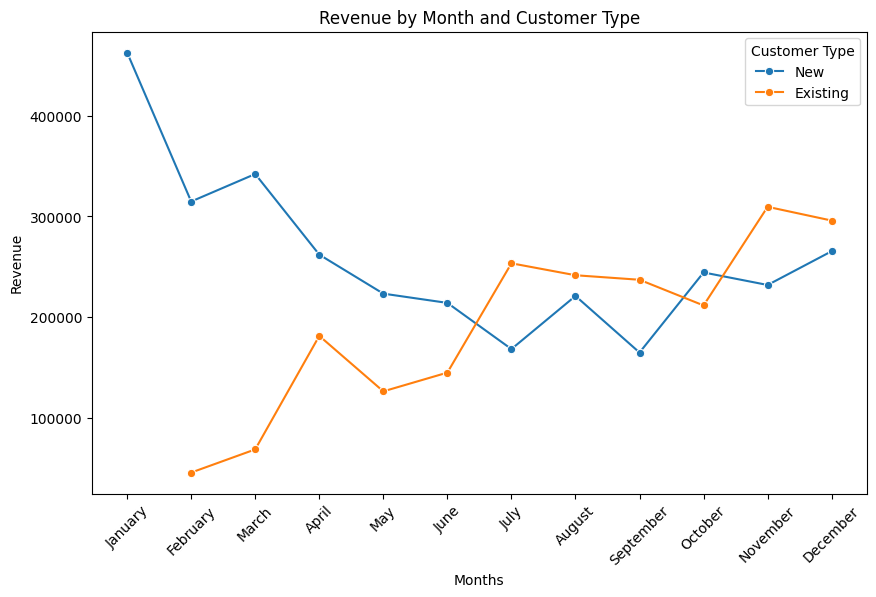

In [ ]:
customer_first = sales_data.groupby('CustomerID', as_index=False)['order_month'].min().rename(columns={'order_month':'first_month'})
sales_customer_first_month = sales_data.merge(customer_first, on='CustomerID', how='left')
sales_customer_first_month['cust_type'] = np.where(sales_customer_first_month['order_month']==sales_customer_first_month['first_month'], 'New', 'Existing')
month_cust_type_rev = sales_customer_first_month.groupby(['order_month', 'cust_type'], as_index=False)['revenue'].sum()
month_cust_type_rev['order_month'] = month_cust_type_rev['order_month'].dt.strftime('%B')
plt.figure(figsize=(10,6))
sns.lineplot(data=month_cust_type_rev, x='order_month', y='revenue',hue='cust_type', marker='o')
plt.xticks(rotation=45)
plt.xlabel('Months')
plt.ylabel('Revenue')
plt.title('Revenue by Month and Customer Type')
plt.legend(title='Customer Type')
plt.show()

# Exisitng customers show month by month increase in revenue though not gradual but a little skewed
# New customers adding also contribute to revenue but month on month is visible till July after which it is comparable with existing xustomers

#Q6

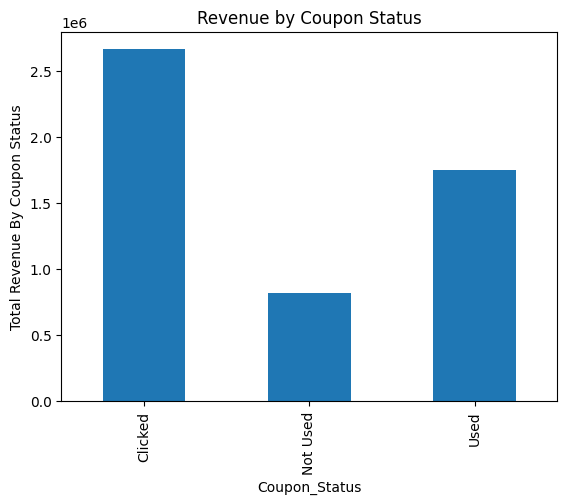

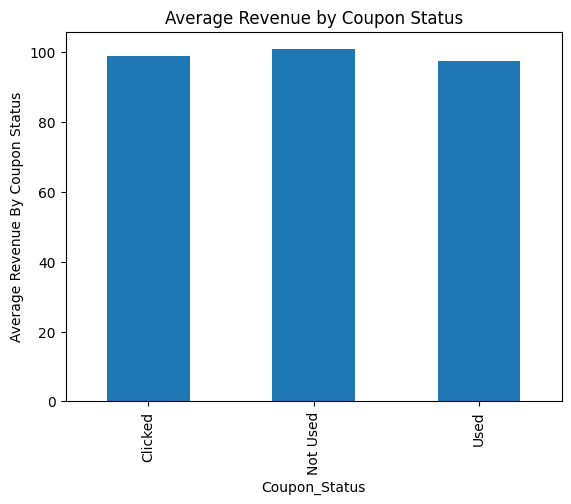

In [ ]:
sales_data['revenue'] = sales_data['Quantity'] * sales_data['Avg_Price'] + sales_data['Delivery_Charges']
coupon_plot = sales_data[['Coupon_Status', 'revenue']].groupby('Coupon_Status')['revenue'].sum()
coupon_plot_avg = sales_data[['Coupon_Status', 'revenue']].groupby('Coupon_Status')['revenue'].mean()
# coupon_plot.drop('Clicked', inplace=True)
# coupon_plot_avg.drop('Clicked', inplace=True)
# coupon_plot.head()
coupon_plot.plot(kind='bar', y='revenue', title='Revenue by Coupon Status')
plt.ylabel('Total Revenue By Coupon Status')
plt.show()
coupon_plot_avg.plot(kind='bar', y='revenue', title='Average Revenue by Coupon Status')
plt.ylabel('Average Revenue By Coupon Status')
plt.show()

# Total revenue generated from Used coupons on transaction is higher compared to not used. So, coupons help in increasing total revenue
# Continuing coupons is a good strategy but can decrease discount percentages going ahead. So, as to not lose on discounts

# Q7

In [ ]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           52924 non-null  int64         
 1   Transaction_ID       52924 non-null  int64         
 2   Transaction_Date     52924 non-null  datetime64[ns]
 3   Product_SKU          52924 non-null  object        
 4   Product_Description  52924 non-null  object        
 5   Product_Category     52924 non-null  object        
 6   Quantity             52924 non-null  int64         
 7   Avg_Price            52924 non-null  float64       
 8   Delivery_Charges     52924 non-null  float64       
 9   Coupon_Status        52924 non-null  object        
 10  order_month          52924 non-null  period[M]     
 11  revenue              52924 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(4), period[M](1)
memory usage: 4.8+ M

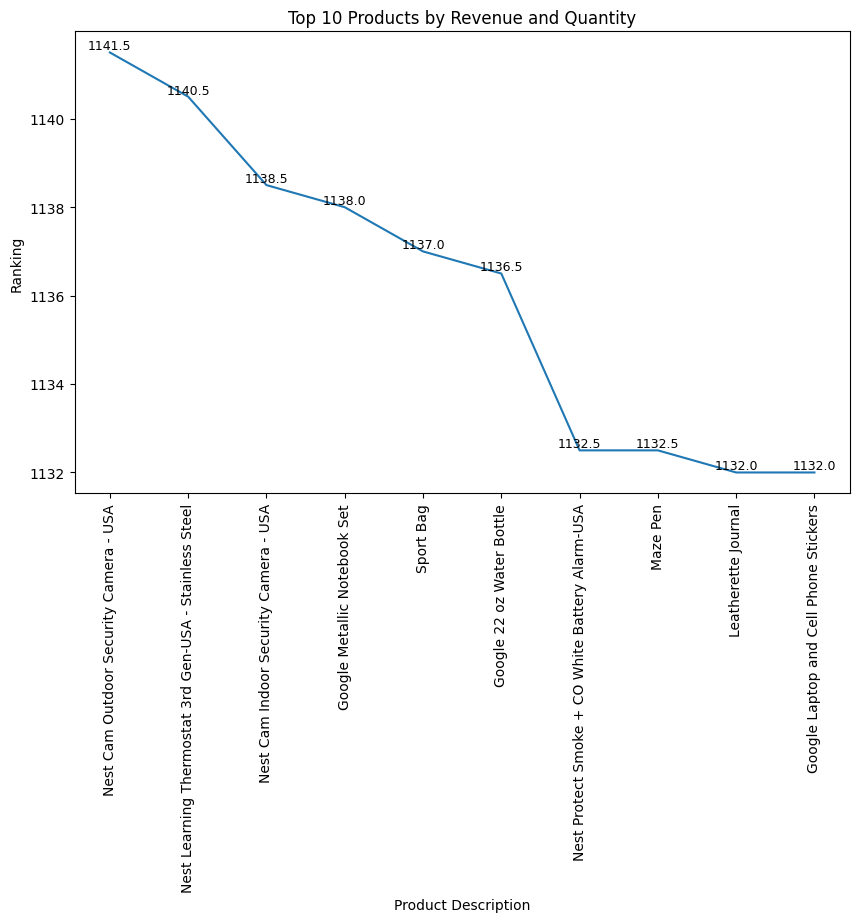

Top 10 Performing Products Are
             Nest Cam Outdoor Security Camera - USA
Nest Learning Thermostat 3rd Gen-USA - Stainles...
             Nest Cam Indoor Security Camera - USA
                      Google Metallic Notebook Set
                                         Sport Bag
                         Google 22 oz Water Bottle
   Nest Protect Smoke + CO White Battery Alarm-USA
                                          Maze Pen
                               Leatherette Journal
             Google Laptop and Cell Phone Stickers


In [ ]:
# product_group_quant = sales_data.groupby('Product_SKU')['Quantity'].sum().sort_values(ascending=False)
# product_group_rev = sales_data.groupby('Product_SKU')['revenue'].sum().sort_values(ascending=False)
# product_group_quant.head()
product_group_perf=sales_data.groupby('Product_SKU').agg(Total_Revenue=('revenue', 'sum'),
                                                         Total_Quantity=('Quantity', 'sum'),
                                                         Product_Description=('Product_Description', 'first'),
                                                         Product_Category=('Product_Category', 'first')
                                                         )
product_group_perf['rank_qty']=product_group_perf['Total_Quantity'].rank(method='min', ascending=True) # min handles ties, higher rank for higher revenue
product_group_perf['rank_rev']=product_group_perf['Total_Revenue'].rank(method='min', ascending=True) # higher rank for higher quantity
product_group_perf['rank_mean']=product_group_perf['rank_qty']*0.5+product_group_perf['rank_rev']*0.5 # mean of ranks
product_group_perf.sort_values(by=['rank_mean','Total_Revenue', 'Total_Quantity'], inplace=True, ascending=[False, False, False])
product_group_perf.reset_index(inplace=True)
product_group_perf.head()
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=product_group_perf.head(10), x='Product_Description', y='rank_mean')
for index, row in product_group_perf.head(10).iterrows():
    plt.text(row['Product_Description'], row['rank_mean'],
             f"{row['rank_mean']}",
             ha='center', va='bottom', fontsize=9, color='black')
plt.title("Top 10 Products by Revenue and Quantity")
plt.xlabel("Product Description")
plt.ylabel("Ranking")
plt.xticks(rotation=90)
plt.show()
print('Top 10 Performing Products Are\n', product_group_perf.head(10)['Product_Description'].to_string(index=False))

# Q8

In [ ]:
marketing_spend_data['total_spend'] = marketing_spend_data['Online_Spend'] + marketing_spend_data['Offline_Spend']
spend_monthly=marketing_spend_data.groupby('month').agg(total_spend=('total_spend', 'sum'))
spend_monthly.reset_index(inplace=True)
# spend_monthly
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
cat_type = pd.CategoricalDtype(categories=month_order, ordered=True)
spend_monthly['month'] = spend_monthly['month'].str.title().astype(cat_type)
spend_monthly.sort_values('month', inplace=True)

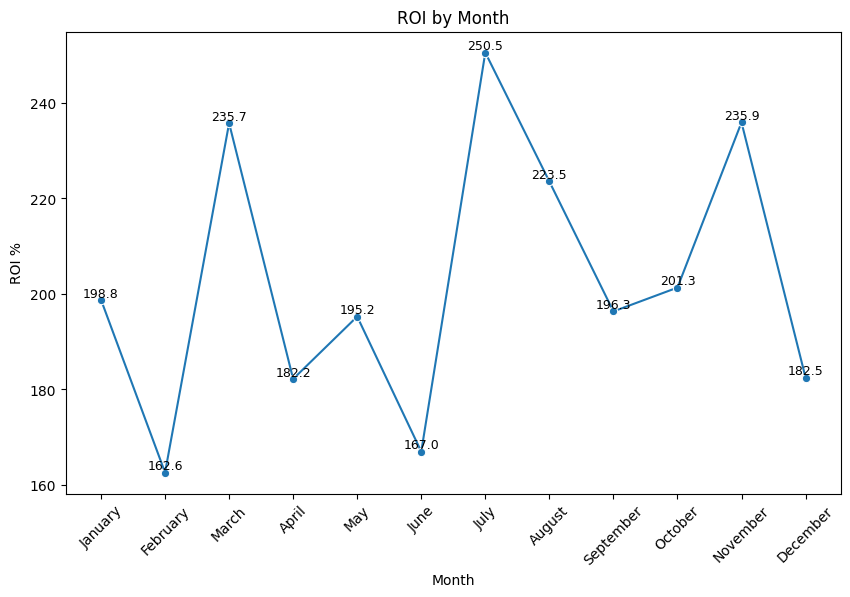

In [ ]:
sales_data['month']= sales_data['Transaction_Date'].dt.month_name()
revenue_monthly = pd.DataFrame(sales_data.groupby('month')['revenue'].sum())
revenue_monthly.reset_index(inplace=True)
revenue_monthly['month'] = revenue_monthly['month'].str.title().astype(cat_type)
revenue_monthly.sort_values('month', inplace=True)
spend_rev_monthly=pd.merge(spend_monthly, revenue_monthly, on='month', how='inner')
spend_rev_monthly['roi'] = (spend_rev_monthly['revenue']-spend_rev_monthly['total_spend'])*100/spend_rev_monthly['total_spend']
plt.figure(figsize=(10, 6))
sns.lineplot(x='month', y='roi', data=spend_rev_monthly, marker='o')
for index, row in spend_rev_monthly.iterrows():
    plt.text(row['month'], row['roi'],
             f"{row['roi']:.1f}",
             ha='center', va='bottom', fontsize=9, color='black')
plt.xlabel('Month')
plt.ylabel('ROI %')
plt.title("ROI by Month")
plt.xticks(rotation=45)
plt.show()

## Particularly Strong in July(250.5) and particularly weak in February(162.6)

# Q9

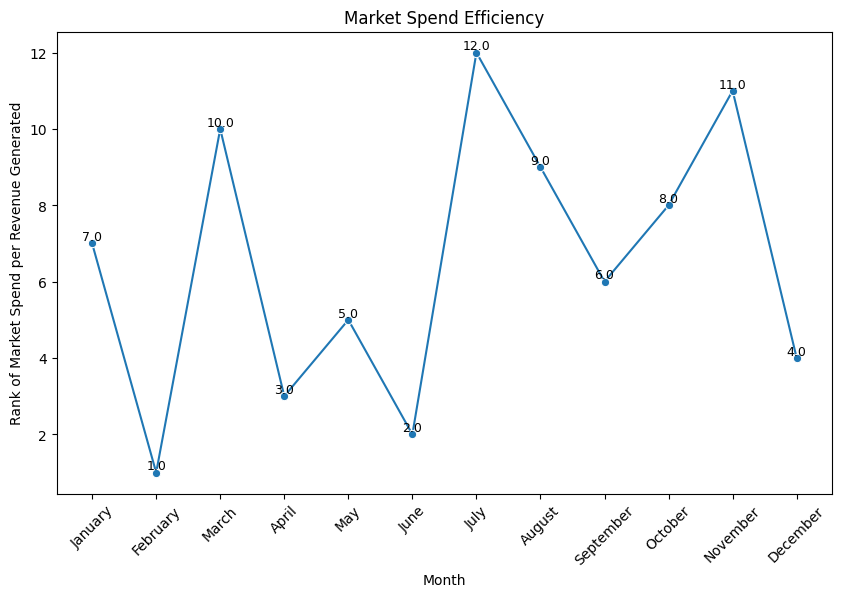

,month,total_spend,revenue,roi,market_spend_%,spend_eff
6,July,120217.85,421362.00,250.498699,28.530776,12.0
10,November,161144.96,541254.55,235.880533,29.772491,11.0
2,March,122250.09,410408.03,235.711843,29.787451,10.0
7,August,142904.15,462309.94,223.510507,30.910897,9.0
9,October,151224.65,455643.16,201.302175,33.189272,8.0
0,January,154928.95,462866.90,198.760755,33.471598,7.0
8,September,135514.54,401553.82,196.317886,33.747541,6.0
4,May,118259.64,349159.59,195.248311,33.869796,5.0
11,December,198648.75,561140.18,182.478586,35.400914,4.0
3,April,157026.83,443100.16,182.181179,35.438225,3.0


In [ ]:
spend_rev_monthly['market_spend_%'] = spend_rev_monthly['total_spend']*100/spend_rev_monthly['revenue']
spend_rev_monthly['spend_eff']=spend_rev_monthly['market_spend_%'].rank(method='min', ascending=False)
spend_rev_monthly.sort_values('spend_eff', inplace=True, ascending=False)

plt.figure(figsize=(10, 6))
sns.lineplot(x='month', y='spend_eff', data=spend_rev_monthly, marker='o')
for index, row in spend_rev_monthly.iterrows():
    plt.text(row['month'], row['spend_eff'],
             f"{row['spend_eff']:.1f}",
             ha='center', va='bottom', fontsize=9, color='black')
plt.xlabel('Month')
plt.ylabel('Rank of Market Spend per Revenue Generated')
plt.title("Market Spend Efficiency")
plt.xticks(rotation=45)
plt.show()
spend_rev_monthly

# Market Spend is least for July (28.5%) and largest for February (38.1)
# Greater the rank least spend on marketing

# Q10

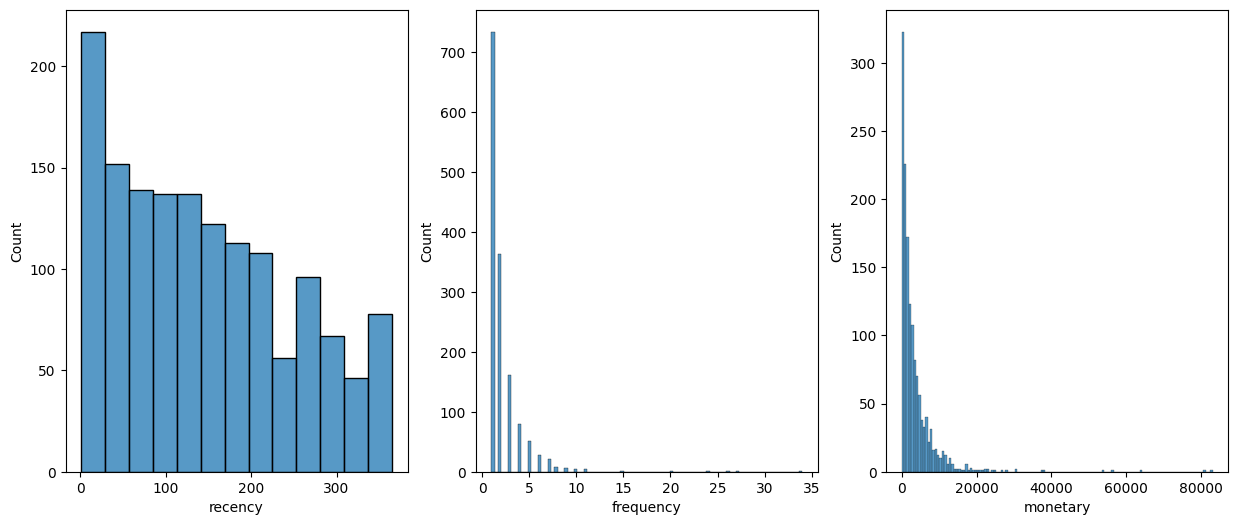

In [ ]:
max_date = sales_data['Transaction_Date'].max()
today=max_date + pd.Timedelta(days=1)
customer_group = sales_data.groupby('CustomerID').agg(
    recency=('Transaction_Date','last'),
    frequency=('Transaction_Date','nunique'),
    monetary=('revenue','sum')
)
customer_group.reset_index(inplace=True)
customer_group['CustomerID'] = customer_group['CustomerID'].astype(str)
customer_group['recency'] = (today - customer_group['recency']).dt.days
customer_group
fig, axes = plt.subplots(ncols=3, figsize=(15,6), sharex=False, sharey=False)
sns.histplot(data=customer_group, x='recency', ax=axes[0])#to decide on bin size
sns.histplot(data=customer_group, x='frequency', ax=axes[1])#to decide on bin size
sns.histplot(data=customer_group, x='monetary', ax=axes[2])#to decide on bin size
plt.show()

In [ ]:
# bins decision
r_bins = [0,100,150,200,np.inf]
f_bins = [0,200,400,700,np.inf]
m_bins = [0,100,200,300,np.inf]
#assign scores
customer_group['r_score'] = pd.cut(customer_group['recency'], bins=r_bins, labels=False)+1
customer_group['f_score'] = pd.cut(customer_group['frequency'], bins=f_bins, labels=False)+1
customer_group['m_score'] = pd.cut(customer_group['monetary'], bins=m_bins, labels=False)+1
customer_group['rfm_score']=customer_group['r_score']+customer_group['f_score']+customer_group['m_score']
# customer_group.groupby('rfm_score')['CustomerID'].count()
def classify_customer(score):
  if score<=4:
    return 'Standard'
  elif score<=6:
    return 'Silver'
  elif score<=8:
    return 'Gold'
  return 'Premium'
customer_group['customer_segment']=customer_group['rfm_score'].apply(classify_customer)

# Q11

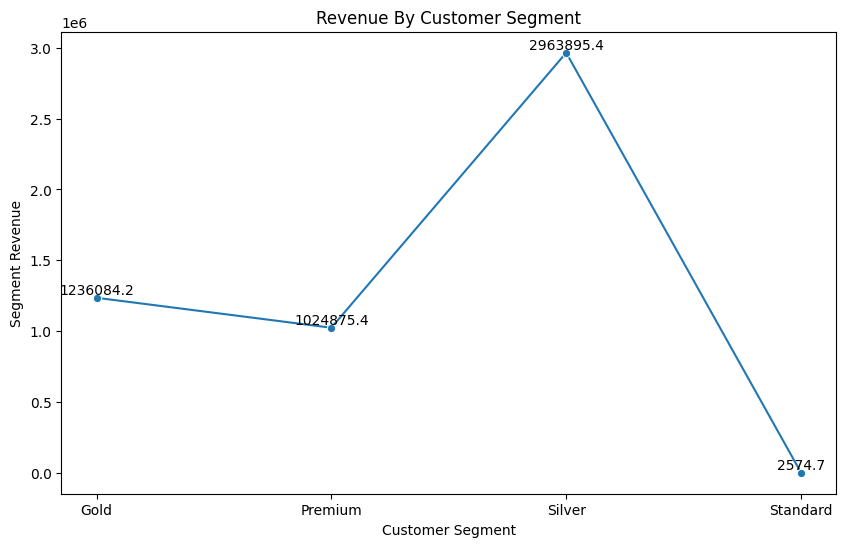

In [ ]:
customer_segment_rev=pd.DataFrame(customer_group.groupby('customer_segment')['monetary'].sum())
customer_segment_rev.reset_index(inplace=True)
plt.figure(figsize=(10,6))
sns.lineplot(data=customer_segment_rev, x='customer_segment', y='monetary', marker='o')
for index, row in customer_segment_rev.iterrows():
    plt.text(row['customer_segment'], row['monetary'],
             f"{row['monetary']:.1f}",
             ha='center', va='bottom')
plt.xlabel('Customer Segment')
plt.ylabel('Segment Revenue')
plt.title('Revenue By Customer Segment')
plt.show()

# Silver segment customers are High Value and Standard segment are low value

# Q12

In [ ]:
# sales_data.drop(columns=['month'], inplace=True)
sales_data['order_month'] = sales_data['Transaction_Date'].dt.to_period('M')
# sales_data

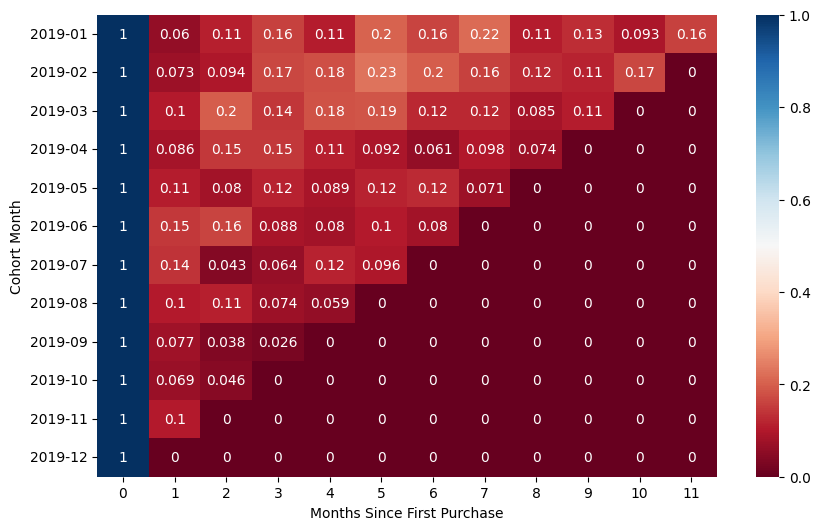

,cohort_month,cohort_size,ret_m1
5,June,137,0.145985
6,July,94,0.138298
4,May,112,0.107143
7,August,135,0.103704
10,November,68,0.102941
2,March,177,0.101695
3,April,163,0.085890
8,September,78,0.076923
1,February,96,0.072917
9,October,87,0.068966


In [ ]:
customer_fist_purchase_month = pd.DataFrame(sales_data.groupby('CustomerID')['order_month'].min().rename('cohort_month'))
customer_fist_purchase_month.reset_index(inplace=True)
# customer_fist_purchase_month
cohort_retention_months = sales_data.merge(customer_fist_purchase_month, on='CustomerID', how='left')
cohort_retention_months['months_since_first_purchase'] = (cohort_retention_months['order_month'] - cohort_retention_months['cohort_month'])
cohort_retention_months['months_since_first_purchase'] = cohort_retention_months['months_since_first_purchase'].apply(lambda x: x.n)
cohort_pivot = cohort_retention_months.groupby(['cohort_month','months_since_first_purchase'])['CustomerID'].nunique().unstack(fill_value=0).sort_index()
cohort_sizes = cohort_pivot.iloc[:,0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)
# retention_matrix['cohort_month'] = retention_matrix['cohort_month'].dt.strftime('%B')
plt.figure(figsize=(10,6))
sns.heatmap(data=retention_matrix, xticklabels=True, yticklabels=True, cmap='RdBu', annot=True)
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.show()
summary =pd.DataFrame(
    {
        'cohort_month':retention_matrix.index.astype(str),
        'cohort_size':cohort_sizes.values,
        'ret_m1':retention_matrix.get(1,pd.Series(index=retention_matrix.index, dtype=float)).values,
    }
)
summary['cohort_month'] = retention_matrix.index.to_timestamp().strftime('%B')
summary.sort_values("ret_m1", ascending=False, inplace=True)
summary
# print("Cohort month with High Retention is:",summary['cohort_month'][0])

# Summary table gives cohort months with highest retention in next month: June

# Q13

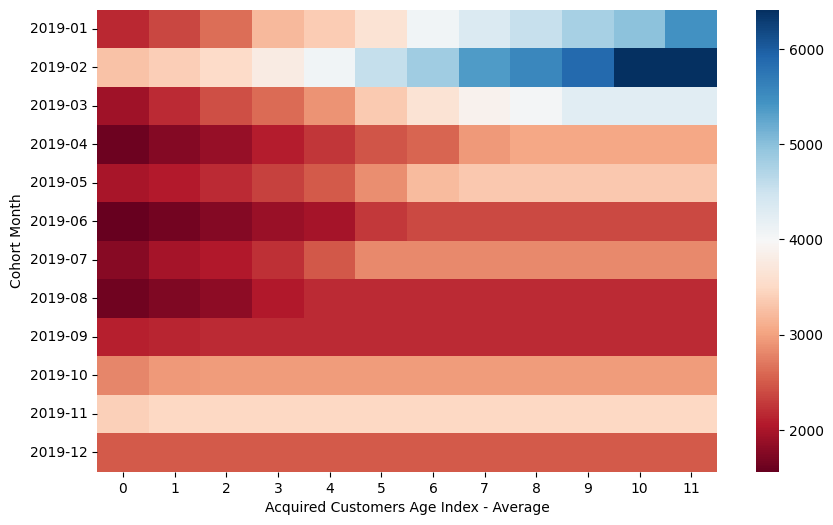

In [ ]:
cust_first_month = sales_data.groupby('CustomerID', as_index=False)['order_month'].min().rename(columns={'order_month':'cohort_month'})
sales_data_first_month = sales_data.merge(cust_first_month, on='CustomerID', how='left')
sales_data_first_month['age_index'] = (sales_data_first_month['order_month'] - sales_data_first_month['cohort_month']).apply(lambda x: x.n)

cust_cohort_age = sales_data_first_month.groupby(['CustomerID', 'cohort_month','age_index'], as_index=False).agg(revenue=('revenue', 'sum'))

# Create a complete timeline for each customer
max_age = cust_cohort_age['age_index'].max()
customer_cohorts = cust_cohort_age[['CustomerID', 'cohort_month']].drop_duplicates()
all_ages = pd.DataFrame({'age_index': range(max_age + 1)})
customer_timeline = customer_cohorts.merge(all_ages, how='cross')

# Merge with actual revenue data and fill missing revenue with 0
cust_panel = customer_timeline.merge(cust_cohort_age, on=['CustomerID', 'cohort_month', 'age_index'], how='left').fillna({'revenue': 0})

# Calculate cumulative revenue
cust_panel['cum_rev'] = cust_panel.groupby(['CustomerID', 'cohort_month'])['revenue'].cumsum()

cust_panel = cust_panel[['CustomerID', 'cohort_month', 'age_index', 'cum_rev']]
# cust_panel

cohort_ltv = cust_panel.groupby(['cohort_month', 'age_index'], as_index=False).agg(
    avg_ltv=('cum_rev','mean')
)
cohort_ltv_pivot = cohort_ltv.pivot(index='cohort_month', columns='age_index', values='avg_ltv')

plt.figure(figsize=(10,6))
sns.heatmap(data=cohort_ltv_pivot, cmap='RdBu')
plt.xlabel('Acquired Customers Age Index - Average')
plt.ylabel('Cohort Month')
plt.show()
# cohort_ltv_pivot

# Acquired Customers For months Jan and Feb in later months (like Nov, Dec) have high revenue generation compared to near cohort age index acquired customers

# Q14

In [ ]:
sales_dat_loc = sales_data.merge(customers_data, on='CustomerID', how='left')
sales_month_cat_loc = sales_dat_loc.groupby(['Product_Category','Location', 'order_month'], as_index=False).agg(
    revenue=('revenue','sum'),
    orders_count=('Transaction_ID', 'nunique'),
    customer_count=('CustomerID','nunique')
)#.unstack(fill_value=0)
seasonality = sales_month_cat_loc.groupby(['Product_Category', 'Location', 'order_month'], as_index=False).agg(
    avg_month_rev=('revenue', 'mean'),
    median_month_rev=('revenue', 'median')
)
baseline = seasonality.groupby(['Product_Category', 'Location'], as_index=False).agg(
    baseline_avg = ('avg_month_rev','mean')
)
seasonality = seasonality.merge(baseline, on=['Product_Category', 'Location'], how='left')
seasonality['seasonal_index'] = seasonality['avg_month_rev']/seasonality['baseline_avg']

def label(si):
  if si>=1.15:
    return 'Peak'
  if si<=0.85:
    return 'Trough'
  return "Normal"

seasonality['label'] = seasonality['seasonal_index'].apply(label)
# seasonality

# Product Heatmap

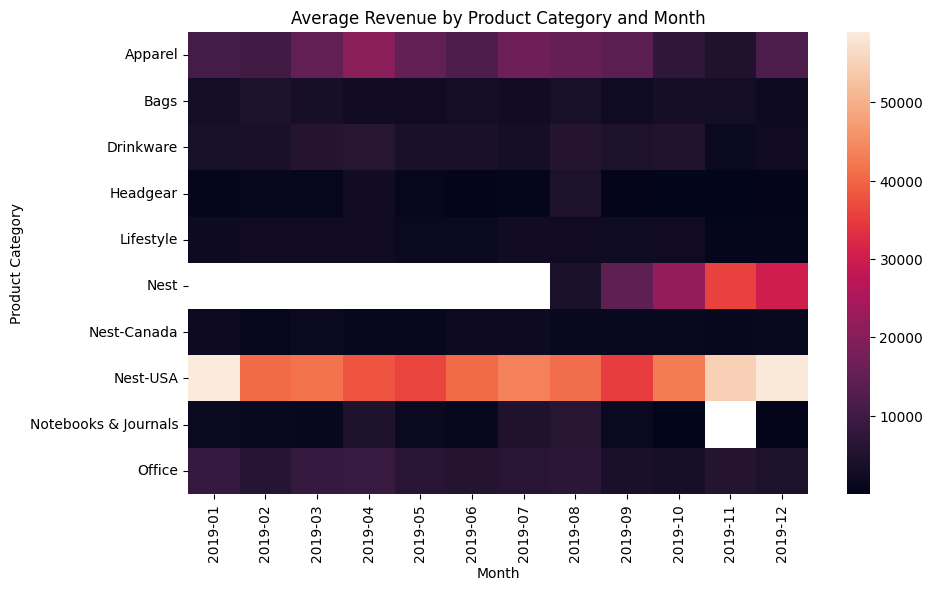

In [ ]:
cat_totals = sales_month_cat_loc.groupby('Product_Category', as_index=False)['revenue'].sum().sort_values('revenue', ascending=False).head(10)
cat_month = sales_month_cat_loc[sales_month_cat_loc['Product_Category'].isin(cat_totals['Product_Category'])].groupby(['Product_Category', 'order_month'], as_index=False)['revenue'].mean()
cat_pivot = cat_month.pivot(index='Product_Category', columns='order_month', values='revenue')

plt.figure(figsize=(10,6))
sns.heatmap(data=cat_pivot)
plt.xlabel('Month')
plt.ylabel('Product Category')
plt.title('Average Revenue by Product Category and Month')
plt.show()

# Location Heatmap

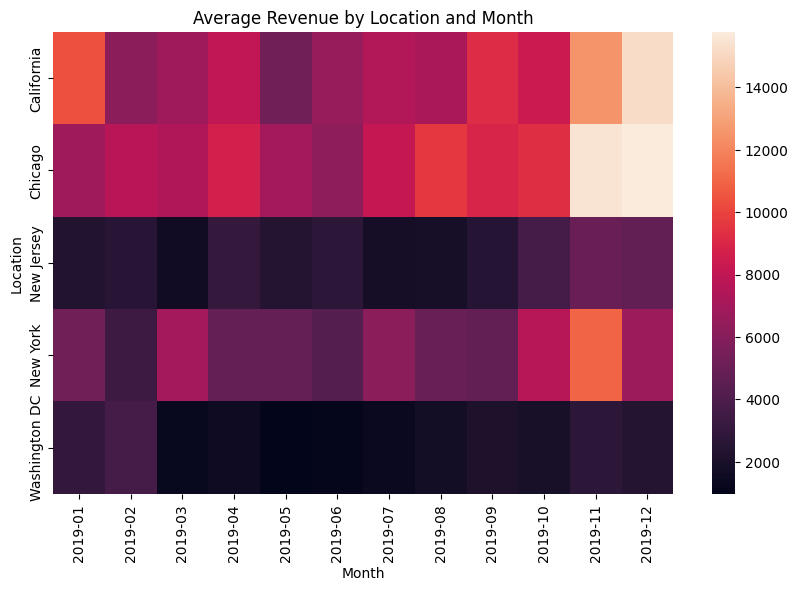

In [ ]:
loc_totals = sales_month_cat_loc.groupby('Location', as_index=False)['revenue'].sum().sort_values('revenue', ascending=False).head(10)
loc_month = sales_month_cat_loc[sales_month_cat_loc['Location'].isin(loc_totals['Location'])].groupby(['Location', 'order_month'], as_index=False)['revenue'].mean()
loc_pivot = loc_month.pivot(index='Location', columns='order_month', values='revenue')

plt.figure(figsize=(10,6))
sns.heatmap(data=loc_pivot)
plt.xlabel('Month')
plt.ylabel('Location')
plt.title('Average Revenue by Location and Month')
plt.show()

# Q15

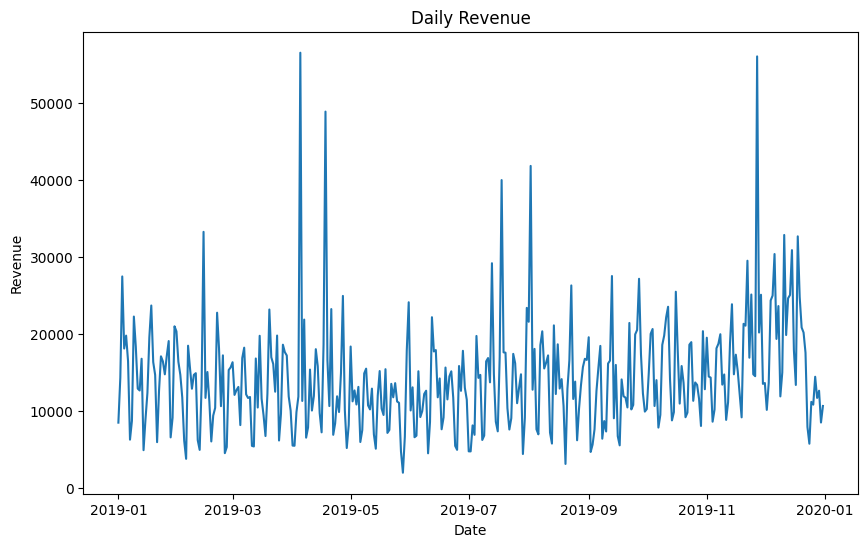

In [ ]:
daily_rev = sales_data.groupby('Transaction_Date', as_index=False)['revenue'].sum().sort_values('revenue', ascending=False)
plt.figure(figsize=(10,6))
sns.lineplot(data=daily_rev, x='Transaction_Date', y='revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.title('Daily Revenue')
# plt.xticks(rotation=90)
plt.show()
# daily_rev['Month']=daily_rev['Transaction_Date'].dt.strftime('%b')
# coupon_daily_rev = daily_rev.head(5).merge(discount_coupon_data, on='Month', how='left')
# coupon_daily_rev.groupby('Month')['Discount_pct'].mean()

In [ ]:
print("Daily Sales Revenue is Higher for", daily_rev.head(5)['Transaction_Date'].to_string(index=False))
print("Daily Sales Revenue is Least for", daily_rev.tail(5)['Transaction_Date'].to_string(index=False))

Daily Sales Revenue is Higher for 2019-04-05
2019-11-27
2019-04-18
2019-08-02
2019-07-18
Daily Sales Revenue is Least for 2019-06-10
2019-07-29
2019-02-05
2019-08-20
2019-05-28
